# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 RoBERTa 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 RoBERTa 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| \ | 是否有承諾 | Yes / No |
| \ | 承諾時程 | already / within_2_years / between_2_and_5_years / longer_than_5_years / N/A |
| \ | 是否有佐證 | Yes / No / N/A |
| \ | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### Related Links
- Competition Main Website：https://veripromiseesg.github.io/
- AI CUP Main Website：https://www.aicup.tw/
- AI CUP Competition Registration Website：https://go.aicup.tw/
- AIDEA Competition Website：https://www.aidea-web.tw/aicup_veripromiseesg
### Reference Links
- SemEval-2025 Task 6: Multinational, Multilingual, Multi-Industry Promise Verification：https://aclanthology.org/2025.semeval-1.321/
- ML-Promise: A Multilingual Dataset for Corporate Promise Verification：https://aclanthology.org/2025.emnlp-main.1028/
- Multilingual Promise Verification in ESG Reports with Large Language Model Performance Evaluation：https://aclanthology.org/2025.rocling-main.32/
- NTCIR：https://research.nii.ac.jp/ntcir/index-en.html

## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [24]:
# 安裝必要套件（Colab 環境）
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q
print("套件安裝完成！")

套件安裝完成！



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# 從 GitHub 下載公開資料集（不需要 Google Drive）
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/ac91c1c8b5d116edf6fc44cccc1ee3b618f5a207/vpesg4ktrain1000v1.json"
urllib.request.urlretrieve(DATA_URL, "vpesg4k_train_1000.json")
print("資料下載完成！")

資料下載完成！


In [26]:
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import math
import re
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# 中文字型設定（Colab）
matplotlib.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')

套件載入完成！
PyTorch 版本: 2.6.0+cu124
CUDA 可用: True


---

## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `hfl/chinese-roberta-wwm-ext`，這是哈工大發布的中文 RoBERTa 模型
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 RoBERTa fine-tuning 使用 2e-5

### 為什麼用 chinese-roberta-wwm-ext？
RoBERTa（Robustly Optimized BERT Pretraining Approach）是 BERT 的改進版本。
- 移除了 Next Sentence Prediction（NSP）任務
- 使用更大的 batch size 與更長的訓練時間
- 採用全詞遮罩（Whole Word Masking, WWM）策略，更適合中文
- 在多項中文 NLP 任務上優於 bert-base-chinese

In [27]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 384
BATCH_SIZE = 4    # 資料集較小（1000筆），使用小 batch size
EPOCHS = 20       # 資料少，多訓練幾個 epoch
LR = 1e-5

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "longer_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤到 ID 的映射
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'最大長度: {MAX_LEN}')
print(f'批次大小: {BATCH_SIZE}')
print(f'訓練輪數: {EPOCHS}')
print(f'標籤數量: {num_labels}')

超參數設定完成！
使用模型: hfl/chinese-roberta-wwm-ext
最大長度: 384
批次大小: 4
訓練輪數: 20
標籤數量: {'promise_status': 2, 'verification_timeline': 5, 'evidence_status': 3, 'evidence_quality': 4}


---

## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [28]:
from sklearn.model_selection import train_test_split

# 載入資料
with open("vpesg4k_train_1000.json", "r", encoding="utf-8") as f:
    all_data = json.load(f)

# 👉 只用一個欄位 stratify（最重要）
stratify_labels = [item["promise_status"] for item in all_data]

train_data, val_data = train_test_split(
    all_data,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

print(f"資料載入成功！共 {len(all_data)} 筆")
print(f"   訓練集大小: {len(train_data)} 筆")
print(f"   驗證集大小: {len(val_data)} 筆")

資料載入成功！共 1000 筆
   訓練集大小: 800 筆
   驗證集大小: 200 筆


---

## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [29]:
# 觀察單筆資料結構
sample = train_data[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10872
  data: 為持續提升公司競爭力與員工專業發展，依據 EMC 訓練體系，2024年度訓練以「強化職能發展，友善學習體驗」為計畫主軸，全面推動各項訓練專案。...
  esg_type: S
  promise_status: Yes
  promise_string: 為持續提升公司競爭力與員工專業發展，
  verification_timeline: already
  evidence_status: Yes
  evidence_string: 2024年度訓練以「強化職能發展，友善學習體驗」為計畫主軸，全面推動各項訓練專案。
  evidence_quality: Clear
  company: emc2
  ticker: 2383
  page_number: 68
  pdf_url: https://hsxn1sjvkgtdpixe.public.blob.vercel-storage.com/emc2_2383_page_68.pdf
  company_source: https://www.emctw.com/zh-TW/csr_report/index


In [30]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                        int64
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                    int64
page_number               int64
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


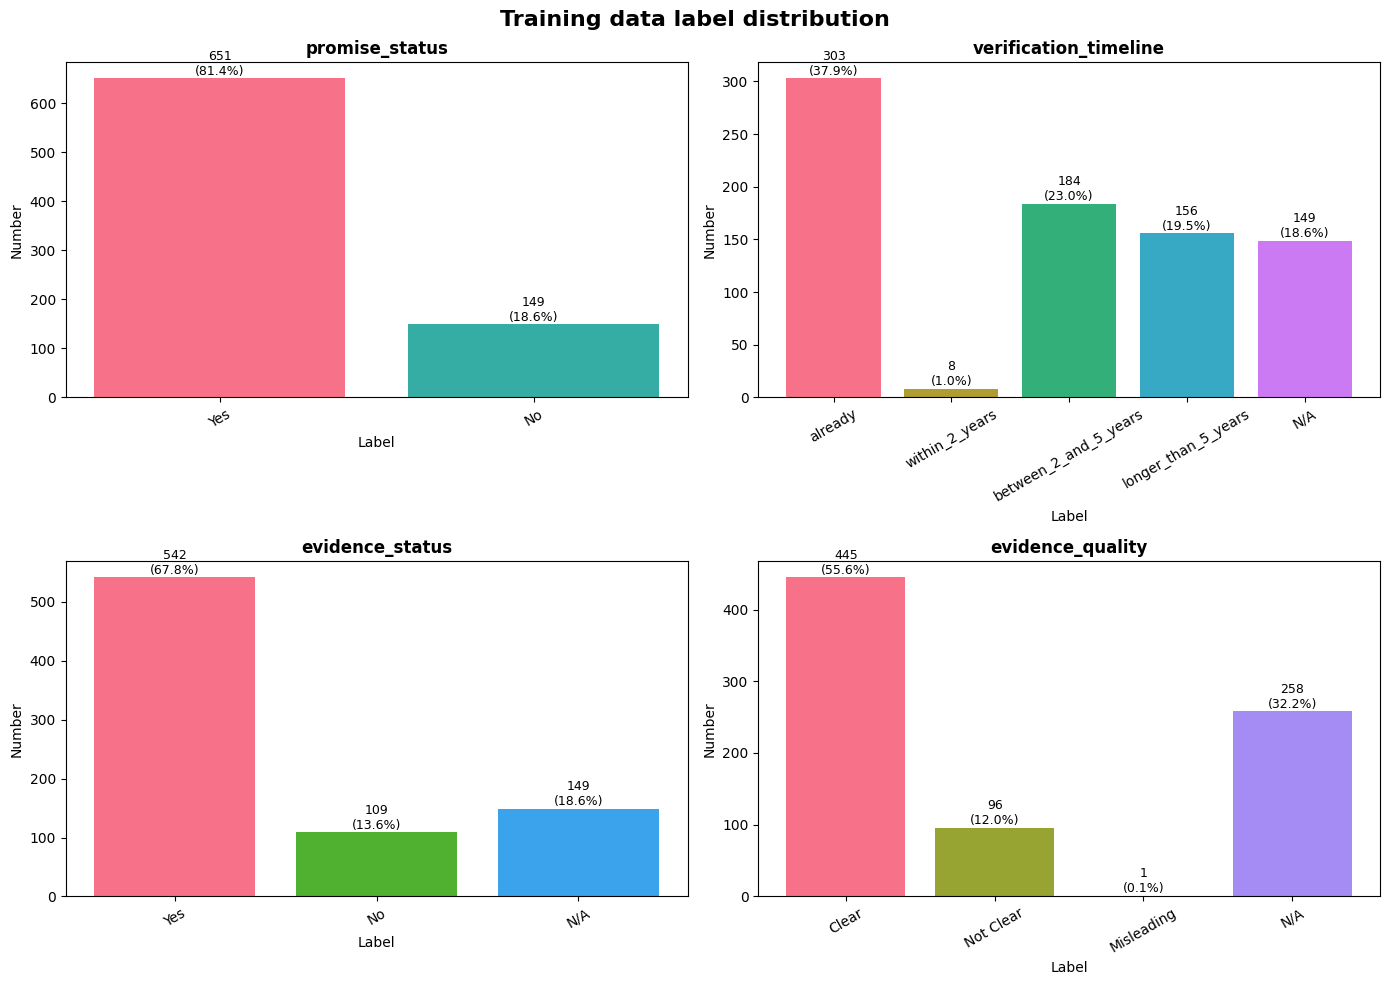

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [31]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training data label distribution", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("Number")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

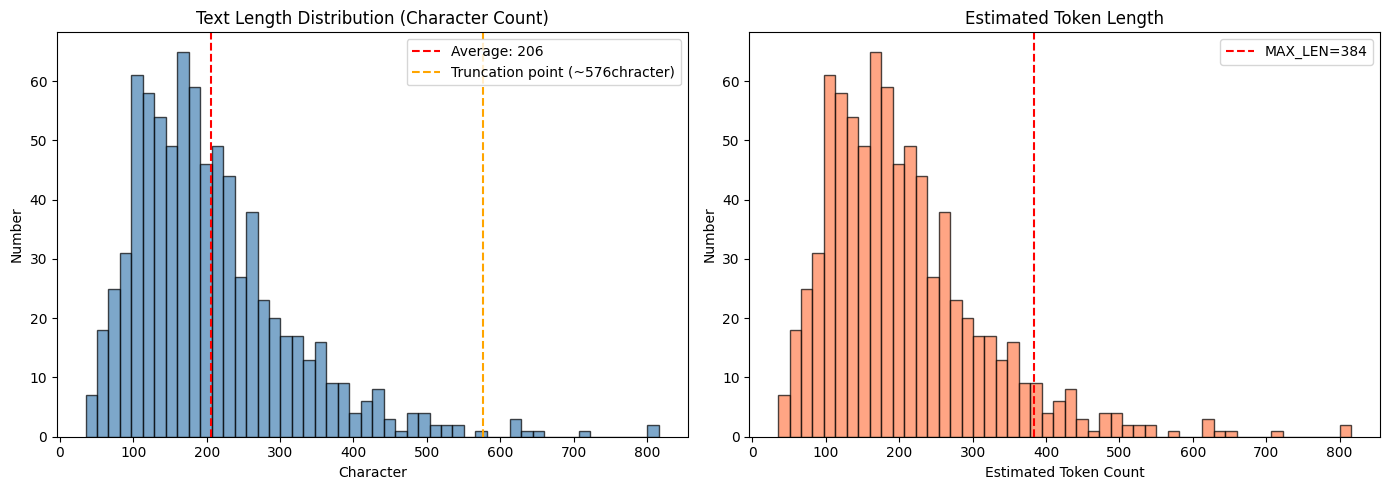

超過 MAX_LEN=384 的樣本數: 49 (6.1%)
   這些文字將被截斷，可能損失尾端資訊


In [32]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"Truncation point (~{MAX_LEN * 1.5:.0f}chracter)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("Character")
axes[0].set_ylabel("Number")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("Estimated Token Count")
axes[1].set_ylabel("Number")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")

---

## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [33]:
# 示範 Tokenizer 的效果
print('Tokenizer 示範')
print('=' * 50)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'載入 {MODEL_NAME} tokenizer')

sample_text = train_data[0]['data'][:50]
print(f'原始文字：{sample_text}')

tokens = tokenizer.tokenize(sample_text)
print(f'Tokenize 後：{tokens}')

encoding = tokenizer(sample_text, max_length=20, padding='max_length', truncation=True)
print(f"Input IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範
載入 hfl/chinese-roberta-wwm-ext tokenizer
原始文字：為持續提升公司競爭力與員工專業發展，依據 EMC 訓練體系，2024年度訓練以「強化職能發展，友善學
Tokenize 後：['為', '持', '續', '提', '升', '公', '司', '競', '爭', '力', '與', '員', '工', '專', '業', '發', '展', '，', '依', '據', 'emc', '訓', '練', '體', '系', '，', '202', '##4', '年', '度', '訓', '練', '以', '「', '強', '化', '職', '能', '發', '展', '，', '友', '善', '學']
Input IDs (前20個)：[101, 4158, 2898, 5265, 2990, 1285, 1062, 1385, 5000, 4261, 1213, 5645, 1519, 2339, 2201, 3511, 4634, 2245, 8024, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [34]:
class ESGDataset(Dataset):
    """
    自定義 PyTorch Dataset，用於處理 ESG 資料
    將文字 Tokenize，並將標籤轉換為 ID
    """
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = "任務：請同時判斷 ESG 承諾、驗證時間、證據狀態與證據品質，並注意文本中的時間描述與證據內容： " + sample['data']
        
        # Tokenize 輸入文字
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # 轉換所有任務的標籤為 ID
        labels = {}
        for field, mapping in self.label2id.items():
            label_text = sample[field]
            labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

def collate_fn(batch):
    """
    自定義 collate_fn，用於 DataLoader 批次處理
    將多個樣本的 input_ids, attention_mask 和各任務的 labels 堆疊成批次張量
    """
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])

    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

# 建立 Dataset 實例
train_dataset = ESGDataset(train_data, tokenizer, label2id)
val_dataset   = ESGDataset(val_data,   tokenizer, label2id)

# 建立 DataLoader（負責批次載入資料）
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # 訓練時打亂順序
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # 驗證時不打亂
    collate_fn=collate_fn
)

print(f"DataLoader 建立完成！")
print(f"   訓練集 Batch 數: {len(train_loader)}")
print(f"   驗證集 Batch 數: {len(val_loader)}")

# 查看一個 batch 的結構
sample_batch = next(iter(train_loader))
print(f"\nBatch 結構：")
print(f"   input_ids shape: {sample_batch['input_ids'].shape}  # [batch_size, seq_len]")
print(f"   attention_mask shape: {sample_batch['attention_mask'].shape}")
for field, tensor in sample_batch['labels'].items():
    print(f"   labels['{field}'] shape: {tensor.shape}")


def compute_class_weights(data, field, label2id):
    counts = Counter([item[field] for item in data])
    total = sum(counts.values())
    num_classes = len(label2id[field])

    weights = []
    for label, idx in sorted(label2id[field].items(), key=lambda x: x[1]):
        count = counts.get(label, 1)

        raw_weight = total / (num_classes * count)
        weight = min(raw_weight, 10.0)   # 🔥 防爆（建議加）

        weights.append(weight)

    return torch.tensor(weights, dtype=torch.float)

# 計算模型參數量
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')
class_weights = {
    field: compute_class_weights(train_data, field, label2id).to(device)
    for field in EVAL_FIELDS
}

print("各任務 class weights：")
for field, weights in class_weights.items():
    print(f"{field}: {weights.cpu().numpy()}")

DataLoader 建立完成！
   訓練集 Batch 數: 200
   驗證集 Batch 數: 50

Batch 結構：
   input_ids shape: torch.Size([4, 384])  # [batch_size, seq_len]
   attention_mask shape: torch.Size([4, 384])
   labels['promise_status'] shape: torch.Size([4])
   labels['verification_timeline'] shape: torch.Size([4])
   labels['evidence_status'] shape: torch.Size([4])
   labels['evidence_quality'] shape: torch.Size([4])
使用裝置: cuda
各任務 class weights：
promise_status: [0.6144393 2.6845639]
verification_timeline: [ 0.5280528 10.         0.8695652  1.0256411  1.0738255]
evidence_status: [0.49200493 2.4464831  1.7897092 ]
evidence_quality: [ 0.4494382  2.0833333 10.         0.7751938]


---

## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 RoBERTa backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[RoBERTa Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
RoBERTa 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [35]:
class MultiTaskModel(nn.Module):
    """
    多任務分類模型
    共用 Encoder，每個任務有自己的分類頭
    """
    def __init__(self, num_labels_dict):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        hidden_size = self.encoder.config.hidden_size

        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden = outputs.last_hidden_state

        mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()

        sum_hidden = torch.sum(last_hidden * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)

        pooled = sum_hidden / sum_mask

        logits = {
            field: clf(pooled)
            for field, clf in self.classifiers.items()
        }

        return logits


# 計算模型參數量
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

model = MultiTaskModel(num_labels).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型參數量：')
print(f'   總參數: {total_params:,}')
print(f'   可訓練參數: {trainable_params:,}')
print(f'   （RoBERTa-base 本身約 1.25億個參數）')

使用裝置: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 49617.55it/s]
BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型參數量：
   總參數: 102,278,414
   可訓練參數: 102,278,414
   （RoBERTa-base 本身約 1.25億個參數）


---

## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [36]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device, class_weights):
    """
    訓練一個 epoch

    Returns:
        avg_loss: 平均損失值
    """
    model.train()
    total_loss = 0

    criterions = {
        field: nn.CrossEntropyLoss(weight=class_weights[field])
        for field in EVAL_FIELDS
    }

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)

        loss = sum(
            criterions[field](
                logits[field],
                batch["labels"][field].to(device)
            )
            for field in EVAL_FIELDS
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def predict(model, dataloader, device, id2label):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}

                for field in EVAL_FIELDS:
                    if field == "verification_timeline":
                        probs = torch.softmax(logits[field][i], dim=0)

                        # 0: already
                        # 1: within_2_years
                        # 2: between_2_and_5_years
                        # 3: longer_than_5_years
                        # 4: N/A
                        probs[1] *= 1.4
                        probs[2] *= 1.2

                        pred_id = probs.argmax().item()
                    else:
                        pred_id = logits[field][i].argmax().item()

                    pred[field] = id2label[field][pred_id]

                predictions.append(pred)

    return predictions


print("訓練與預測函數定義完成！")

訓練與預測函數定義完成！


In [37]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


---

## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [38]:
# 設定優化器與學習率排程器
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"訓練設定：")
print(f"   Total steps: {total_steps}")
print(f"   Warmup steps: {warmup_steps} (前 10%)")
print(f"   Learning rate: {LR}")
print(f"   Optimizer: AdamW")

訓練設定：
   Total steps: 4000
   Warmup steps: 400 (前 10%)
   Learning rate: 1e-05
   Optimizer: AdamW


In [39]:
# ============================================================
# 主訓練迴圈（固定跑滿 EPOCHS，不使用 early stopping）
# ============================================================
MODEL_SAVE_PATH = "best_model.pt"

best_score = 0.0
best_epoch = 0
history = {"loss": [], "weighted_score": []}

print("開始訓練！")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, class_weights)
    history["loss"].append(avg_loss)
    print(f"  平均 Loss: {avg_loss:.4f}")

    preds = predict(model, val_loader, device, id2label)
    results = evaluate_hybrid(val_data, preds)

    current_score = results["final_weighted_score"]
    history["weighted_score"].append(current_score)

    print(f"\n  加權分數: {current_score:.5f}")
    for field in EVAL_FIELDS:
        r = results[field]
        print(f"     {field}: Macro F1={r['macro_f1']:.4f} (權重={r['weight']})")

    if current_score > best_score + 1e-6:
        best_score = current_score
        best_epoch = epoch + 1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"\n最佳模型已儲存！分數: {best_score:.5f} (Epoch {best_epoch})")

print(f"\n{'=' * 60}")
print(f"訓練完成！最佳加權分數: {best_score:.5f} (Epoch {best_epoch})")

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\utils\_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "c:\Users\USER\AppData\Local\Programs\Python\Python310\lib\threading.py", line

開始訓練！

Epoch 1/20
----------------------------------------
  Step 50/200, Loss: 4.7443
  Step 100/200, Loss: 4.6904
  Step 150/200, Loss: 4.0436
  Step 200/200, Loss: 4.4509
  平均 Loss: 4.4546

  加權分數: 0.30714
     promise_status: Macro F1=0.4766 (權重=0.2)
     verification_timeline: Macro F1=0.1566 (權重=0.15)
     evidence_status: Macro F1=0.2921 (權重=0.3)
     evidence_quality: Macro F1=0.2877 (權重=0.35)

最佳模型已儲存！分數: 0.30714 (Epoch 1)

Epoch 2/20
----------------------------------------
  Step 50/200, Loss: 4.2110
  Step 100/200, Loss: 3.5876
  Step 150/200, Loss: 2.8555
  Step 200/200, Loss: 1.8435
  平均 Loss: 3.9395

  加權分數: 0.46673
     promise_status: Macro F1=0.6629 (權重=0.2)
     verification_timeline: Macro F1=0.3659 (權重=0.15)
     evidence_status: Macro F1=0.5239 (權重=0.3)
     evidence_quality: Macro F1=0.3489 (權重=0.35)

最佳模型已儲存！分數: 0.46673 (Epoch 2)

Epoch 3/20
----------------------------------------
  Step 50/200, Loss: 4.4468
  Step 100/200, Loss: 3.3252
  Step 150/200, Loss: 4.

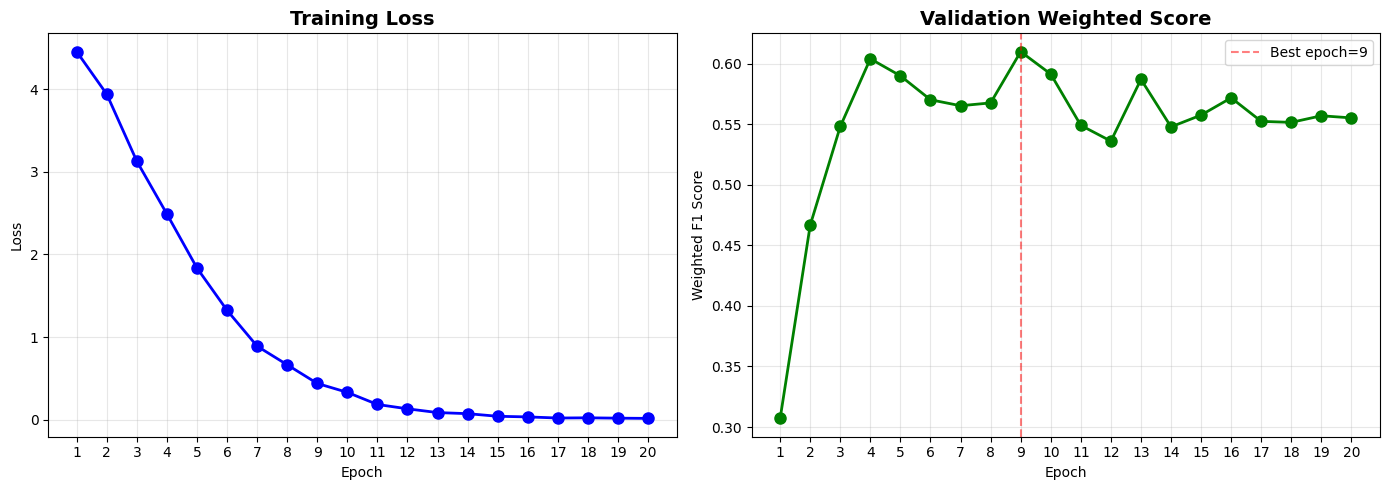

In [40]:
# 繪製訓練曲線
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["loss"]) + 1)

axes[0].plot(epochs_range, history["loss"], 'b-o', linewidth=2, markersize=8)
axes[0].set_title("Training Loss", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

axes[1].plot(epochs_range, history["weighted_score"], 'g-o', linewidth=2, markersize=8)
axes[1].set_title("Validation Weighted Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))

# 標記最佳點
best_epoch = history["weighted_score"].index(max(history["weighted_score"])) + 1
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch={best_epoch}')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [41]:
# 載入最佳模型
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f"已載入最佳模型")

# 最終預測
final_preds = predict(model, val_loader, device, id2label)
final_results = evaluate_hybrid(val_data, final_preds)

print(f"\n{'=' * 60}")
print(f"最終評估結果")
print(f"{'=' * 60}")

for field in EVAL_FIELDS:
    r = final_results[field]
    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")

print(f"\n{'=' * 60}")
print(f"最終加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")



已載入最佳模型

最終評估結果

--- promise_status (權重: 0.2) ---
              precision    recall  f1-score   support

         Yes       0.90      0.93      0.92       163
          No       0.66      0.57      0.61        37

    accuracy                           0.86       200
   macro avg       0.78      0.75      0.76       200
weighted avg       0.86      0.86      0.86       200

  Macro F1: 0.7636
  Micro F1: 0.8650

--- verification_timeline (權重: 0.15) ---
                       precision    recall  f1-score   support

              already       0.49      0.59      0.53        63
       within_2_years       1.00      0.40      0.57         5
between_2_and_5_years       0.57      0.59      0.58        54
  longer_than_5_years       0.79      0.66      0.72        41
                  N/A       0.66      0.57      0.61        37

             accuracy                           0.59       200
            macro avg       0.70      0.56      0.60       200
         weighted avg       0.62     

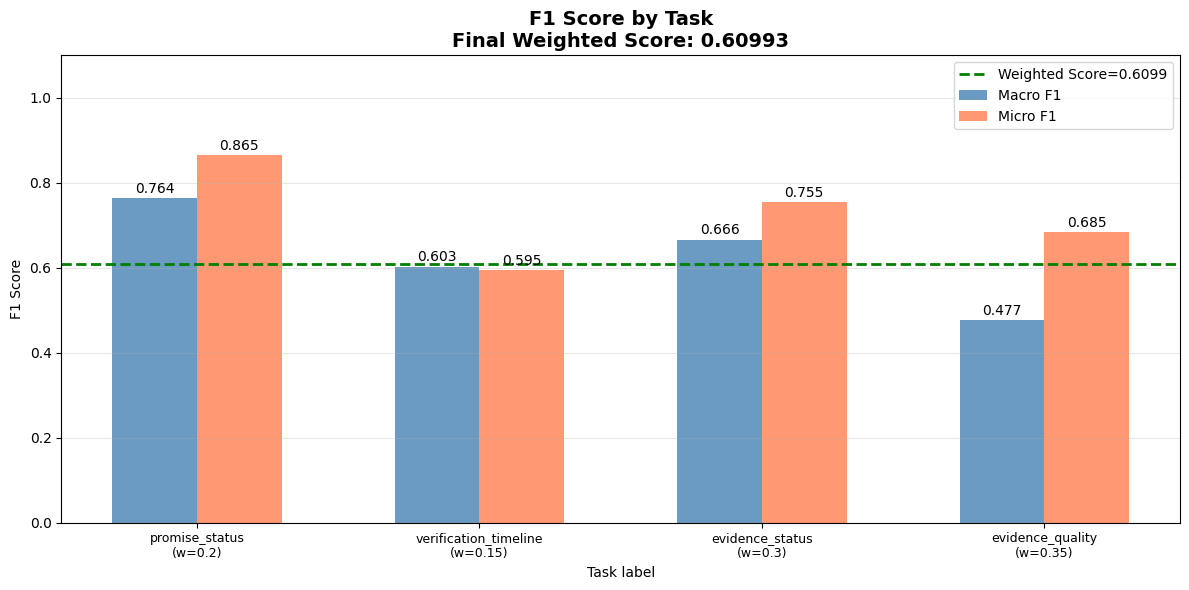

In [42]:
# 視覺化各欄位的 F1 分數
fields = list(EVAL_FIELDS.keys())
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
micro_f1s = [final_results[f]["micro_f1"] for f in fields]
weights   = [FIELD_WEIGHTS[f] for f in fields]

x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='coral',     alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Task label")
ax.set_ylabel("F1 Score")
ax.set_title(f"F1 Score by Task\nFinal Weighted Score: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
           linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# 儲存預測結果
OUTPUT_PATH = "prediction.json"

output_data = []
for orig, pred in zip(val_data, final_preds):
    item = dict(orig)   # 複製原始資料
    item.update(pred)   # 覆蓋預測欄位
    output_data.append(item)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 預測結果已儲存至: {OUTPUT_PATH}")
print(f"   共 {len(output_data)} 筆")

# 顯示前3筆預測結果
print("\n📋 前3筆預測結果：")
for i, item in enumerate(output_data[:3]):
    print(f"\n--- 第{i+1}筆 (ID: {item.get('id', 'N/A')}) ---")
    for field in EVAL_FIELDS:
        print(f"  {field}: {item[field]}")

✅ 預測結果已儲存至: prediction.json
   共 200 筆

📋 前3筆預測結果：

--- 第1筆 (ID: 10366) ---
  promise_status: Yes
  verification_timeline: between_2_and_5_years
  evidence_status: No
  evidence_quality: Not Clear

--- 第2筆 (ID: 10375) ---
  promise_status: No
  verification_timeline: N/A
  evidence_status: N/A
  evidence_quality: N/A

--- 第3筆 (ID: 10042) ---
  promise_status: Yes
  verification_timeline: longer_than_5_years
  evidence_status: Yes
  evidence_quality: Not Clear


In [44]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\USER\Desktop\劉董專案\AI_CUP
['.venv', '2026_ai_cup.ipynb', 'best_model.pt', 'f1_scores.png', 'label_distribution.png', 'prediction.json', 'submission.csv', 'training_curve.png', 'vpesg4k_test_2000.csv', 'vpesg4k_train_1000 V1.csv', 'vpesg4k_train_1000 V1.json', 'vpesg4k_train_1000.json']


In [51]:
# ============================================================
# AIDEA Test 2000 推論 + 產生 submission.csv
# ============================================================

from tqdm import tqdm
import pandas as pd
import torch
import csv

test_df = pd.read_csv("vpesg4k_test_2000.csv")

print("測試集筆數:", len(test_df))

submission_rows = []

model.eval()

with torch.no_grad():

    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

        text = (
            "任務：請同時判斷 ESG 承諾、驗證時間、證據狀態與證據品質，"
            "並注意文本中的時間描述與證據內容： "
            + str(row["data"])
        )

        encoding = tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        result = {"id": row["id"]}

        for field in EVAL_FIELDS:
            pred_id = torch.argmax(outputs[field], dim=1).item()
            result[field] = id2label[field][pred_id]

        if result["promise_status"] == "No":
            result["verification_timeline"] = "N/A"
            result["evidence_status"] = "N/A"
            result["evidence_quality"] = "N/A"

        elif result["evidence_status"] == "No":
            result["evidence_quality"] = "N/A"

        submission_rows.append(result)

submission = pd.DataFrame(submission_rows)

submission = submission[
    [
        "id",
        "promise_status",
        "verification_timeline",
        "evidence_status",
        "evidence_quality"
    ]
]

submission["verification_timeline"] = submission["verification_timeline"].replace(
    "longer_than_5_years",
    "more_than_5_years"
)

for col in [
    "promise_status",
    "verification_timeline",
    "evidence_status",
    "evidence_quality"
]:
    submission[col] = submission[col].astype(str)
    submission[col] = submission[col].str.strip()
    submission[col] = submission[col].replace("nan", "N/A")
    submission[col] = submission[col].replace("None", "N/A")
    submission[col] = submission[col].replace("", "N/A")

submission = submission.fillna("N/A")

print("空值檢查：")
print(submission.isna().sum())

print("verification_timeline 類別：")
print(submission["verification_timeline"].unique())

print("evidence_status 類別：")
print(submission["evidence_status"].unique())

print("evidence_quality 類別：")
print(submission["evidence_quality"].unique())

submission.to_csv(
    "submission.csv",
    index=False,
    encoding="utf-8",
    quoting=csv.QUOTE_MINIMAL
)

# 重新讀一次確認 AIDEA 看到的內容
check = pd.read_csv("submission.csv", keep_default_na=False)

print("重新讀檔後空值檢查：")
print(check.isna().sum())

print("重新讀檔後 N/A 數量：")
print((check == "N/A").sum())

print("完成")
print(check.shape)

check.head()

測試集筆數: 2000


100%|██████████| 2000/2000 [00:23<00:00, 85.71it/s]

空值檢查：
id                       0
promise_status           0
verification_timeline    0
evidence_status          0
evidence_quality         0
dtype: int64
verification_timeline 類別：
['already' 'between_2_and_5_years' 'more_than_5_years' 'N/A'
 'within_2_years']
evidence_status 類別：
['Yes' 'No' 'N/A']
evidence_quality 類別：
['Clear' 'N/A' 'Not Clear']
重新讀檔後空值檢查：
id                       0
promise_status           0
verification_timeline    0
evidence_status          0
evidence_quality         0
dtype: int64
重新讀檔後 N/A 數量：
id                         0
promise_status             0
verification_timeline    340
evidence_status          343
evidence_quality         745
dtype: int64
完成
(2000, 5)


,id,promise_status,verification_timeline,evidence_status,evidence_quality
0,12001,Yes,already,Yes,Clear
1,12002,Yes,between_2_and_5_years,Yes,Clear
2,12003,Yes,already,Yes,Clear
3,12004,Yes,between_2_and_5_years,Yes,Clear
4,12005,Yes,already,Yes,Clear


---

## Step 10: 進階改進方向

恭喜你完成了基礎版本！以下是幾個可以進一步提升分數的方向：

### 1. 模型升級
```python
# 可以嘗試更大的模型
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"  # 中文 RoBERTa Large
MODEL_NAME = "bert-large-chinese"                   # BERT Large
```

### 2. 加入 Dropout 防止過擬合
```python
self.dropout = nn.Dropout(0.1)
pooled = self.dropout(outputs.pooler_output)
```

### 3. 損失加權（針對類別不均衡）
```python
# 給少數類別更高的損失權重
criterion = nn.CrossEntropyLoss(weight=class_weights)
```

### 4. 資料增強
- 同義詞替換
- 回譯（中→英→中）
- 隨機遮罩

### 5. 集成學習（Ensemble）
```python
# 訓練多個模型，取預測結果的多數票
from collections import Counter
ensemble_pred = Counter([model1_pred, model2_pred, model3_pred]).most_common(1)[0][0]
```

### 6. 調整超參數
- 增加 Epochs（10-15）
- 調整 Learning Rate（1e-5 ~ 5e-5）
- 增大 MAX_LEN（512）
- 嘗試不同 BATCH_SIZE

---
## 工作坊總結

今天我們學習了：
1. ESG 承諾驗證任務的定義
2. 使用 EDA 分析資料分佈
3. 實作 PyTorch Dataset & DataLoader
4. 設計 Multi-Task BERT 模型架構
5. 完整的訓練、評估、預測流程
6. 使用加權 Macro F1 評分

**祝大家在比賽中取得好成績！**